# Práctica 4 - REGLAS DE ASOCIACIÓN (ALGORITMO APRIORI)

En esta práctica, dado un dataset de partidas de ajedrez, lo que se pide es crear unas reglas de asociación sobre dicho dataset y analizar aquellas que son más significativas. 
A la hora de usar el algoritmo Apriori, se usará la librería mlxtend, que es la más popular y recomendada, dado que tiene una buena integración con pandas, teniendo una salida en DataFrame, lo cual simplifica el filtrado y el análisis. Con sus funciones, se pueden generar itemsets frecuentes y reglas de asociación

In [2]:
#Primero, se importan las librerías que se usarán, como pandas, mlxtend, matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import gc
import os

Lo primero que se pide en la práctica es el preprocesamiento de los datos, realizando algunas sustituciones en los datos.......

In [3]:
CHUNK_SIZE = 50_000 # Se define el tamano de los chunks para procesar el CSV por partes, evitando cargar el dataset entero en cada iteracion
CSV_PATH   = "lichess_games.csv"
# Ademas, se especifica el nombre del fichero y de las columnas que se van a usar del CSV
COLS = ['WhiteElo', 'BlackElo', 'MovesCount', 'TimeControl',
        'Result', 'Termination', 'Opening', 'ECO']

#Para categorizar el Elo y el numero de jugadas, se crea una funcion a parte para cada uno
#Lo que hara la funcion categorizar_elo es asignar una categoria de nivel, en base a unas metricas
def categorizar_elo(elo):
    if   elo < 1200: return 'Principiante'
    elif elo < 1600: return 'Intermedio'
    elif elo < 2000: return 'Avanzado'
    elif elo < 2400: return 'Experto'
    elif elo < 2800: return 'Maestro'
    else:            return 'Gran Maestro'

#La funcion categorizar_jugadas hace algo similar, pero con la duracion de la partida
def categorizar_jugadas(n):
    if   n < 20: return 'Corta'
    elif n < 40: return 'Media'
    elif n < 60: return 'Larga'
    else:        return 'Muy larga'


# Aqui defino una funcion para simplificar la interpretabilidad y el codigo en general del bucle que lee el dataset
# De esta manera modifico los campos necesarios
def procesar_chunk(chunk):
    #Primero, se sustituyen los valores faltantes por el valor 900 y se convierten a enteros
    chunk['WhiteElo'] = chunk['WhiteElo'].replace('?', 900).astype(int)
    chunk['BlackElo'] = chunk['BlackElo'].replace('?', 900).astype(int)

    chunk.dropna(subset=COLS, inplace=True)

    #Una vez se sustituyen los valores, se puede categorizar todo el Elo y el numero de jugadas
    #Para ello, se aplican las funciones creadas anteriormente en las columnas que corresponden
    chunk['WhiteEloCategory'] = chunk['WhiteElo'].apply(categorizar_elo)
    chunk['BlackEloCategory'] = chunk['BlackElo'].apply(categorizar_elo)
    chunk['MovesCategory'] = chunk['MovesCount'].apply(categorizar_jugadas)

    #Por ultimo, se limpian los datos de las columnas que se indican, eliminando los espacios en blanco
    #Ademas, se convierten a mayusculas para que asi no se tengan problemas a la hora de hacer el analisis posterior con el algoritmo
    chunk['Result'] = chunk['Result'].str.strip()
    chunk['Termination'] = chunk['Termination'].str.strip().str.title()
    chunk['Opening'] = chunk['Opening'].str.strip()
    chunk['ECO'] = chunk['ECO'].str.strip().str.upper()

    return chunk

# Ficheros de salida
OUTPUT_600 = "lichess_600.csv"
OUTPUT_60  = "lichess_60.csv"

# Borramos si existían de ejecuciones anteriores para no duplicar datos
for f in [OUTPUT_600, OUTPUT_60]:
    if os.path.exists(f): os.remove(f)

# Bucle principal: Procesamos y volcamos a disco inmediatamente
for i, chunk in enumerate(pd.read_csv(CSV_PATH, usecols=COLS, chunksize=CHUNK_SIZE)):
    chunk = procesar_chunk(chunk)

    mask_600 = chunk['TimeControl'] == '600+0'
    mask_60  = chunk['TimeControl'] == '60+0'

    # Si hay coincidencias, escribimos en modo 'append' (a)
    # Ponemos header=True SOLO la primera vez que se escribe el fichero
    if mask_600.any():
        chunk[mask_600].to_csv(OUTPUT_600, mode='a', index=False, header=not os.path.exists(OUTPUT_600))
    if mask_60.any():
        chunk[mask_60].to_csv(OUTPUT_60, mode='a', index=False, header=not os.path.exists(OUTPUT_60))
    
    # Cada 20 chunks forzamos una limpieza radical de la memoria volátil
    if i % 20 == 0:
        gc.collect()

Una vez se preprocesan los datos, habría que aplicar el algoritmo. Pero primero es necesario explicar cómo funciona la librería mlxtend que se usará para aplicar el algoritmo apriori.

## Funcionamiento de la librería mlxtend para reglas de asociación

El flujo que espera mlxtend siempre es el mismo: datos -> TransactionEncoder -> apriori -> association_rules

1. TransactionEncoder: esta función convierte una lista de listas en una tabla con una columna por cada valor único que apareció en alguna fila, y True donde ese valor estaba presente. Cada fila conformará una transacción, por lo que esta tabla tiene el formato perfecto que requiere Apriori.

2. Apriori: ya sabemos que este algoritmo extrae los conjuntos de items frecuentes. Esta función, entonces, aplica el algoritmo tomando como parámetros el dataframe que calculamos antes y el soporte mínimo (hay más parámetros opcionales); dando como resultado un dataframe con esos conjuntos más frecuentes y los soportes.

3. Association_rules: aquí es donde se generan las reglas. Esta función toma como parámetro obligatorio el dataframe anterior y genera uno nuevo con una regla por fila (A -> C) y las columnas antecedente, consecuente, soporte, confianza y lift.

## Para el subconjunto '600+0':

In [4]:
CSV_600_PATH = "lichess_600.csv"
df_600_raw = pd.read_csv(CSV_600_PATH)

# Voy a usar una muestra del subconjunto para agilizar el proceso
df_600 = df_600_raw.sample(n=500_000, random_state=42)
del df_600_raw

# Creamos la tabla de las transacciones, donde cada lista interior representa una partida, con el elo de las blancas y las negras, el resultado, si la partida duró mucho o poco y cómo terminó
transacciones = df_600.apply(
    lambda row: [
        f"White:{row['WhiteEloCategory']}",
        f"Black:{row['BlackEloCategory']}",
        f"Result:{row['Result']}",
        f"Moves:{row['MovesCategory']}",
        f"Term:{row['Termination']}",
    ],
    axis = 1
).tolist()

te = TransactionEncoder()
te_ary = te.fit(transacciones).transform(transacciones)
df_enc = pd.DataFrame(te_ary, columns=te.columns_)

# Usamos la función apriori para hallar los itemsets más frecuentes con un soporte mínimo modificable
frequent_itemsets = apriori(df_enc, min_support=0.05, use_colnames=True)

# Por último, generamos las reglas con un lift mínimo para comprobar que tengan sentido y sean buenas
reglas = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.0,
    num_itemsets=len(df_enc)
)

# Mostramos las 10 más significativas
top10 = reglas.sort_values('lift', ascending=False).head(10)
print(top10[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

                                           antecedents  \
121                         frozenset({White:Experto})   
118            frozenset({Term:Normal, Black:Experto})   
11                          frozenset({White:Experto})   
10                          frozenset({Black:Experto})   
120                         frozenset({Black:Experto})   
119            frozenset({Term:Normal, White:Experto})   
568       frozenset({Term:Normal, Black:Principiante})   
569        frozenset({White:Principiante, Result:1-0})   
573                    frozenset({Black:Principiante})   
564  frozenset({Term:Normal, White:Principiante, Re...   

                                           consequents   support  confidence  \
121            frozenset({Term:Normal, Black:Experto})  0.053262    0.675331   
118                         frozenset({White:Experto})  0.053262    0.771376   
11                          frozenset({Black:Experto})  0.060796    0.770858   
10                          frozenset({Wh

Ahora pasamos a la parte de la verificación de las reglas, para ello, se definen unos parámetros globales, seguidos de una función para evaluar cada una de las reglas.

In [5]:
# Para comparar si un rango es mayor que otro, necesitamos convertir las etiquetas a números, de manera que sean comparables
orden_elo = {'Principiante': 0, 'Intermedio': 1, 'Avanzado': 2,
             'Experto': 3, 'Maestro': 4, 'Gran Maestro': 5}

# Luego, creamos la columna rank para cada color y aplicamos ese orden para toda la columna con .map
df_600['WhiteElo_rank'] = df_600['WhiteEloCategory'].map(orden_elo)
df_600['BlackElo_rank'] = df_600['BlackEloCategory'].map(orden_elo)


In [6]:
# Para que la función pueda usarse para todas las reglas, lo que va a hacerse es ponerse en una función
# De esta manera, sólo habrá que pasarle el antecedente y el consecuente, calculando las métricas automáticamente para cada una

resultados = [] # Se crea una array para guardar los valores de las métricas y luego poder graficarlas

def verificar_regla(mask_ant, mask_cons, nombre_regla, total, subset):

    if mask_ant.sum() == 0:
        soporte = 0.0
        confianza = 0.0
        lift = 0.0 
    else:
        # Esta es la función que calculará las métricas y las mostrará por pantalla
        soporte = (mask_ant & mask_cons).sum() / total
        confianza = (mask_ant & mask_cons).sum() / mask_ant.sum()
        lift = confianza / (mask_cons.sum() / total)

    # Una vez se tienen las métricas, se muestran por la pantalla para que se puedan analizar los resultados
    print(f"\nNombre de la regla: {nombre_regla}")
    print(f"\nSoporte: {soporte:4f}")
    print(f"\nConfianza: {confianza:4f}")
    print(f"\nLift: {lift:4f}")

    resultados.append({
        'Regla':      nombre_regla,
        'Subset':     subset,
        'Soporte':    round(soporte, 4),
        'Confianza':  round(confianza, 4),
        'Lift':       round(lift, 4)
    })


Una vez se tiene la función que calculará las métricas necesarias para evaluar las reglas, se procede a pasarle los datos para cada una se ellas, pero primero va:
**Verificar si es una posible regla el hecho de que si la diferencia de Elo entre los jugadores es mayor o igual a una categoría entonces el jugador más fuerte gana la partida. Diferenciar entre si el jugador más fuerte juega con blancas o con negras:**

In [7]:
# Como hay que diferenciar entre que el más fuerte juegue con blancas o con negras, se preguntará dos veces a la función y se
# verá cuaĺ de las dos reglas tiene mejores estadísticas, para poder ver si es mejor que el más fuerte juegue con blancas o negras

mask_ant_white = (df_600['WhiteElo_rank'] - df_600['BlackElo_rank']) >= 1 # Antecedente: White es al menos una categoría mejor que Black
mask_ant_black = (df_600['BlackElo_rank'] - df_600['WhiteElo_rank']) >= 1

mask_cons_white = df_600['Result'] == '1-0' # Consecuente: ganan las blancas
mask_cons_black  = df_600['Result'] == '0-1'

verificar_regla(mask_ant_white, mask_cons_white, "Más fuerte con BLANCAS (>=1 categoría) -> gana", len(df_600), "600+0")
verificar_regla(mask_ant_black, mask_cons_black,  "Más fuerte con NEGRAS (>=1 categoría) -> gana", len(df_600), "600+0")


Nombre de la regla: Más fuerte con BLANCAS (>=1 categoría) -> gana

Soporte: 0.039202

Confianza: 0.616422

Lift: 1.244709

Nombre de la regla: Más fuerte con NEGRAS (>=1 categoría) -> gana

Soporte: 0.037656

Confianza: 0.587182

Lift: 1.288155


Regla a verificar: **Verificar si es una posible regla el hecho de que si la diferencia de Elo entre los jugadores es mayor o igual a dos categorías entonces el jugador más fuerte gana la partida. Diferenciar entre si el jugador más fuerte juega con blancas o con negras.**

In [8]:
# Esta regla es igual a la anterior, con la única diferencia de que la diferencia de categorías debe ser 2 o más

mask_ant_white = (df_600['WhiteElo_rank'] - df_600['BlackElo_rank']) >= 2 # Antecedente: White es al menos dos categorías mejor que Black
mask_ant_black = (df_600['BlackElo_rank'] - df_600['WhiteElo_rank']) >= 2

mask_cons_white = df_600['Result'] == '1-0' # Consecuente: ganan las blancas
mask_cons_black  = df_600['Result'] == '0-1'

verificar_regla(mask_ant_white, mask_cons_white, "Más fuerte con BLANCAS (>=2 categorías) -> gana", len(df_600), "600+0")
verificar_regla(mask_ant_black, mask_cons_black,  "Más fuerte con NEGRAS (>=2 categorías) -> gana", len(df_600), "600+0")


Nombre de la regla: Más fuerte con BLANCAS (>=2 categorías) -> gana

Soporte: 0.003212

Confianza: 0.842602

Lift: 1.701423

Nombre de la regla: Más fuerte con NEGRAS (>=2 categorías) -> gana

Soporte: 0.003214

Confianza: 0.844900

Lift: 1.853534


Regla a verificar: **Verificar si es una posible regla el hecho de que si los jugadores son Grandes Maestros entonces la partida finaliza en tablas (Result=“1/2-1/2”). Diferenciar entre el número de jugadas.**

In [9]:
# Para esta regla, se compara por el número de jugadas, en lugar de por el Elo, entonces, para ello, necesitaremos un bucle
# Con ese bucle, se podrá llamar a la función que verifica las reglas para cada una de las jugadas.

# Sin embargo, primero definimos el consecuente, que debe ser el mismo para todas las jugadas
mask_cons3 = df_600['Result'] == "1/2-1/2" # Consecuente: tablas

# También se puede definir una parte del consecuente antes, si los jugadores son Grandes Maestros o no
mask_gm = (df_600['WhiteEloCategory'] == 'Gran Maestro') & (df_600['BlackEloCategory'] == 'Gran Maestro')

# Luego, se itera por cada jugada
for jugada in ['Corta', 'Media', 'Larga', 'Muy larga']:
    mask_moves = df_600['MovesCategory'] == jugada
    verificar_regla(mask_gm & mask_moves, mask_cons3, f"Ambos GM + {jugada} -> tablas", len(df_600), "600+0")


Nombre de la regla: Ambos GM + Corta -> tablas

Soporte: 0.000000

Confianza: 0.000000

Lift: 0.000000

Nombre de la regla: Ambos GM + Media -> tablas

Soporte: 0.000004

Confianza: 1.000000

Lift: 21.315599

Nombre de la regla: Ambos GM + Larga -> tablas

Soporte: 0.000002

Confianza: 1.000000

Lift: 21.315599

Nombre de la regla: Ambos GM + Muy larga -> tablas

Soporte: 0.000006

Confianza: 0.375000

Lift: 7.993350


Regla a verificar: **Verificar si es una posible regla el hecho de que si los jugadores son Grandes Maestros entonces la partida finaliza con victoria de las blancas (Result=“1-0”). Diferenciar entre el número de jugadas.**

In [10]:
# Para esta regla, se comprueba si las blancas ganan si los jugadores son grandes maestros
# El antecedente será que ambos tengan esa categoría, junto con la jugada
# El consecuente será que ganen las blancas

mask_ant4 = mask_gm # Usamos lo mismo que definimos en la celda anterior para el antecedente, ya que es el mismo
mask_cons4 = df_600['Result'] == '1-0'

for categoria in ['Corta', 'Media', 'Larga', 'Muy larga']:
    mask_moves = df_600['MovesCategory'] == categoria
    verificar_regla(mask_ant4 & mask_moves, mask_cons4, f"Ambos GM + {categoria} -> gana blancas", len(df_600), "600+0")


Nombre de la regla: Ambos GM + Corta -> gana blancas

Soporte: 0.000000

Confianza: 0.000000

Lift: 0.000000

Nombre de la regla: Ambos GM + Media -> gana blancas

Soporte: 0.000000

Confianza: 0.000000

Lift: 0.000000

Nombre de la regla: Ambos GM + Larga -> gana blancas

Soporte: 0.000000

Confianza: 0.000000

Lift: 0.000000

Nombre de la regla: Ambos GM + Muy larga -> gana blancas

Soporte: 0.000010

Confianza: 0.625000

Lift: 1.262030


Regla a verificar: **Verificar si es una posible regla el hecho de que si los jugadores son ajedrecistas principiantes o de nivel intermedio, entonces la partida finaliza con victoria de las blancas (Result=“1-0”).**

In [11]:
# En esta regla, en lugar de tener sólo una categoría, hay dos, principiante e intermedio
# Cada uno puede pertenecer a una categoría diferente, uno puede ser principiante y el otro intermedio, o ambos iguales
mask_ant5 = (df_600['WhiteEloCategory'].isin(['Principiante', 'Intermedio'])) & (df_600['BlackEloCategory'].isin(['Principiante', 'Intermedio']))
mask_cons5 = df_600['Result'] == '1-0'

verificar_regla(mask_ant5, mask_cons5, "Ambos Principiante/Intermedio -> gana blancas", len(df_600), "600+0")


Nombre de la regla: Ambos Principiante/Intermedio -> gana blancas

Soporte: 0.267656

Confianza: 0.498174

Lift: 1.005937


Regla a verificar: **Verificar si es una posible regla el hecho de que la partida termine normal (Termination=“Normal”) o por tiempo perdido (Termination=“Time forfeit”) cuando el ritmo de juego es relámpago (TimeControl=“600+0”). Diferenciar entre el número de jugadas.**

In [12]:
# Como hay que diferenciar entre el número de jugadas, usaremos el bucle de nuevo
# Además, también hay que diferenciar entre las terminaciones del juego

mask_cons_normal = df_600['Termination'] == 'Normal' 
mask_cons_forfeit = df_600['Termination'] == 'Time Forfeit'


for categoria in ['Corta', 'Media', 'Larga', 'Muy larga']:
    mask_moves = df_600['MovesCategory'] == categoria
    verificar_regla(mask_moves & (df_600['TimeControl'] == '600+0'), mask_cons_normal, f"Partida {categoria} y ritmo Relámpago -> termina Normal", len(df_600), "600+0")
    verificar_regla(mask_moves & (df_600['TimeControl'] == '600+0'), mask_cons_forfeit,  f"Partida {categoria} y ritmo Relámpago -> termina por tiempo", len(df_600), "600+0")


Nombre de la regla: Partida Corta y ritmo Relámpago -> termina Normal

Soporte: 0.192916

Confianza: 0.860226

Lift: 0.978737

Nombre de la regla: Partida Corta y ritmo Relámpago -> termina por tiempo

Soporte: 0.026164

Confianza: 0.116667

Lift: 1.006862

Nombre de la regla: Partida Media y ritmo Relámpago -> termina Normal

Soporte: 0.433694

Confianza: 0.918567

Lift: 1.045116

Nombre de la regla: Partida Media y ritmo Relámpago -> termina por tiempo

Soporte: 0.038416

Confianza: 0.081365

Lift: 0.702200

Nombre de la regla: Partida Larga y ritmo Relámpago -> termina Normal

Soporte: 0.184682

Confianza: 0.840801

Lift: 0.956637

Nombre de la regla: Partida Larga y ritmo Relámpago -> termina por tiempo

Soporte: 0.034968

Confianza: 0.159199

Lift: 1.373919

Nombre de la regla: Partida Muy larga y ritmo Relámpago -> termina Normal

Soporte: 0.067622

Confianza: 0.805542

Lift: 0.916519

Nombre de la regla: Partida Muy larga y ritmo Relámpago -> termina por tiempo

Soporte: 0.0163

## Para el subconjunto '60+0':

In [13]:
CSV_60_PATH = "lichess_60.csv"
df_60_raw = pd.read_csv(CSV_60_PATH)

# Voy a usar una muestra del subconjunto para agilizar el proceso
df_60 = df_60_raw.sample(n=500_000, random_state=42)
del df_60_raw

transacciones = df_60.apply(
    lambda row: [
        f"White:{row['WhiteEloCategory']}",
        f"Black:{row['BlackEloCategory']}",
        f"Result:{row['Result']}",
        f"Moves:{row['MovesCategory']}",
        f"Term:{row['Termination']}",
    ],
    axis = 1
).tolist()

te = TransactionEncoder()
te_ary = te.fit(transacciones).transform(transacciones)
df_enc = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = apriori(df_enc, min_support=0.05, use_colnames=True)

reglas = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.0,
    num_itemsets=len(df_enc)
)

# Mostramos las 10 más significativas
top10 = reglas.sort_values('lift', ascending=False).head(10)
print(top10[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

                                           antecedents  \
263                    frozenset({Black:Principiante})   
258  frozenset({Term:Time Forfeit, White:Principian...   
262                    frozenset({White:Principiante})   
259  frozenset({Term:Time Forfeit, Black:Principian...   
30                     frozenset({White:Principiante})   
31                     frozenset({Black:Principiante})   
252       frozenset({Moves:Media, White:Principiante})   
257                    frozenset({Black:Principiante})   
253       frozenset({Moves:Media, Black:Principiante})   
256                    frozenset({White:Principiante})   

                                           consequents   support  confidence  \
263  frozenset({Term:Time Forfeit, White:Principian...  0.054114    0.626073   
258                    frozenset({Black:Principiante})  0.054114    0.899561   
262  frozenset({Term:Time Forfeit, Black:Principian...  0.054114    0.626769   
259                    frozenset({White:P

Ahora, se hace lo mismo de la verificación de reglas, pero para el subconjunto de 60+0. Para esta parte, se usará la misma función de verificación que se definió para el subconjunto 600+0. 

In [14]:
# Definimos los parámetros globales que se usarán en esta práctica
orden_elo = {'Principiante': 0, 'Intermedio': 1, 'Avanzado': 2,
             'Experto': 3, 'Maestro': 4, 'Gran Maestro': 5}

# Luego, creamos la columna rank para cada color y aplicamos ese orden para toda la columna con .map
df_60['WhiteElo_rank'] = df_60['WhiteEloCategory'].map(orden_elo)
df_60['BlackElo_rank'] = df_60['BlackEloCategory'].map(orden_elo)

Regla a verificar: **Verificar si es una posible regla el hecho de que si la diferencia de Elo entre los jugadores es mayor o igual a una categoría entonces el jugador más fuerte gana la partida. Diferenciar entre si el jugador más fuerte juega con blancas o con negras:**

In [15]:
mask_ant_white = (df_60['WhiteElo_rank'] - df_60['BlackElo_rank']) >= 1 # Antecedente: White es al menos una categoría mejor que Black
mask_ant_black = (df_60['BlackElo_rank'] - df_60['WhiteElo_rank']) >= 1

mask_cons_white = df_60['Result'] == '1-0' # Consecuente: ganan las blancas
mask_cons_black  = df_60['Result'] == '0-1'

verificar_regla(mask_ant_white, mask_cons_white, "Más fuerte con BLANCAS (>=1 categoría) -> gana", len(df_60), "60+0")
verificar_regla(mask_ant_black, mask_cons_black,  "Más fuerte con NEGRAS (>=1 categoría) -> gana", len(df_60), "60+0")


Nombre de la regla: Más fuerte con BLANCAS (>=1 categoría) -> gana

Soporte: 0.037926

Confianza: 0.628184

Lift: 1.259912

Nombre de la regla: Más fuerte con NEGRAS (>=1 categoría) -> gana

Soporte: 0.036518

Confianza: 0.601416

Lift: 1.275100


Regla a verificar: **Verificar si es una posible regla el hecho de que si la diferencia de Elo entre los jugadores es mayor o igual a dos categorías entonces el jugador más fuerte gana la partida. Diferenciar entre si el jugador más fuerte juega con blancas o con negras.**

In [16]:
mask_ant_white = (df_60['WhiteElo_rank'] - df_60['BlackElo_rank']) >= 2 # Antecedente: White es al menos dos categorías mejor que Black
mask_ant_black = (df_60['BlackElo_rank'] - df_60['WhiteElo_rank']) >= 2

mask_cons_white = df_60['Result'] == '1-0' # Consecuente: ganan las blancas
mask_cons_black  = df_60['Result'] == '0-1'

verificar_regla(mask_ant_white, mask_cons_white, "Más fuerte con BLANCAS (>=2 categorías) -> gana", len(df_60), "60+0")
verificar_regla(mask_ant_black, mask_cons_black,  "Más fuerte con NEGRAS (>=2 categorías) -> gana", len(df_60), "60+0")


Nombre de la regla: Más fuerte con BLANCAS (>=2 categorías) -> gana

Soporte: 0.003162

Confianza: 0.887205

Lift: 1.779414

Nombre de la regla: Más fuerte con NEGRAS (>=2 categorías) -> gana

Soporte: 0.003152

Confianza: 0.881925

Lift: 1.869824


Regla a verificar: **Verificar si es una posible regla el hecho de que si los jugadores son Grandes Maestros entonces la partida finaliza en tablas (Result=“1/2-1/2”). Diferenciar entre el número de jugadas.**

In [17]:
mask_cons3 = df_60['Result'] == "1/2-1/2" # Consecuente: tablas

# También se puede definir una parte del consecuente antes, si los jugadores son Grandes Maestros o no
mask_gm = (df_60['WhiteEloCategory'] == 'Gran Maestro') & (df_60['BlackEloCategory'] == 'Gran Maestro')

# Luego, se itera por cada jugada
for jugada in ['Corta', 'Media', 'Larga', 'Muy larga']:
    mask_moves = df_60['MovesCategory'] == jugada
    verificar_regla(mask_gm & mask_moves, mask_cons3, f"Ambos GM + {jugada} -> tablas", len(df_60), "60+0")


Nombre de la regla: Ambos GM + Corta -> tablas

Soporte: 0.000004

Confianza: 0.017241

Lift: 0.603690

Nombre de la regla: Ambos GM + Media -> tablas

Soporte: 0.000020

Confianza: 0.016502

Lift: 0.577789

Nombre de la regla: Ambos GM + Larga -> tablas

Soporte: 0.000066

Confianza: 0.062264

Lift: 2.180117

Nombre de la regla: Ambos GM + Muy larga -> tablas

Soporte: 0.000146

Confianza: 0.214706

Lift: 7.517713


Regla a verificar: **Verificar si es una posible regla el hecho de que si los jugadores son Grandes Maestros entonces la partida finaliza con victoria de las blancas (Result=“1-0”). Diferenciar entre el número de jugadas.**

In [18]:
mask_ant4 = mask_gm # Usamos lo mismo que definimos en la celda anterior para el antecedente, ya que es el mismo
mask_cons4 = df_60['Result'] == '1-0'

for categoria in ['Corta', 'Media', 'Larga', 'Muy larga']:
    mask_moves = df_60['MovesCategory'] == categoria
    verificar_regla(mask_ant4 & mask_moves, mask_cons4, f"Ambos GM + {categoria} -> gana blancas", len(df_60), "60+0")


Nombre de la regla: Ambos GM + Corta -> gana blancas

Soporte: 0.000122

Confianza: 0.525862

Lift: 1.054690

Nombre de la regla: Ambos GM + Media -> gana blancas

Soporte: 0.000660

Confianza: 0.544554

Lift: 1.092180

Nombre de la regla: Ambos GM + Larga -> gana blancas

Soporte: 0.000506

Confianza: 0.477358

Lift: 0.957409

Nombre de la regla: Ambos GM + Muy larga -> gana blancas

Soporte: 0.000280

Confianza: 0.411765

Lift: 0.825852


Regla a verificar: **Verificar si es una posible regla el hecho de que si los jugadores son ajedrecistas principiantes o de nivel intermedio, entonces la partida finaliza con victoria de las blancas (Result=“1-0”).**

In [19]:
mask_ant5 = (df_60['WhiteEloCategory'].isin(['Principiante', 'Intermedio'])) & (df_60['BlackEloCategory'].isin(['Principiante', 'Intermedio']))
mask_cons5 = df_60['Result'] == '1-0'

verificar_regla(mask_ant5, mask_cons5, "Ambos Principiante/Intermedio -> gana blancas", len(df_60), "60+0")


Nombre de la regla: Ambos Principiante/Intermedio -> gana blancas

Soporte: 0.147354

Confianza: 0.500782

Lift: 1.004388


Regla a verificar: **Verificar si es una posible regla el hecho de que la partida termine normal (Termination=“Normal”) o por tiempo perdido (Termination=“Time forfeit”) cuando el ritmo de juego es relámpago (TimeControl=“600+0”). Diferenciar entre el número de jugadas.**

In [21]:
mask_cons_normal = df_60['Termination'] == 'Normal' 
mask_cons_forfeit = df_60['Termination'] == 'Time Forfeit'


for categoria in ['Corta', 'Media', 'Larga', 'Muy larga']:
    mask_moves = df_60['MovesCategory'] == categoria
    verificar_regla(mask_moves  & (df_60['TimeControl'] == '60+0'), mask_cons_normal, f"Partida {categoria} y ritmo Relámpago -> termina Normal", len(df_60), "60+0")
    verificar_regla(mask_moves  & (df_60['TimeControl'] == '60+0'), mask_cons_forfeit,  f"Partida {categoria} y ritmo Relámpago -> termina por tiempo", len(df_60), "60+0")


Nombre de la regla: Partida Corta y ritmo Relámpago -> termina Normal

Soporte: 0.103322

Confianza: 0.763493

Lift: 1.738705

Nombre de la regla: Partida Corta y ritmo Relámpago -> termina por tiempo

Soporte: 0.029516

Confianza: 0.218107

Lift: 0.390597

Nombre de la regla: Partida Media y ritmo Relámpago -> termina Normal

Soporte: 0.263926

Confianza: 0.446742

Lift: 1.017366

Nombre de la regla: Partida Media y ritmo Relámpago -> termina por tiempo

Soporte: 0.326854

Confianza: 0.553258

Lift: 0.990803

Nombre de la regla: Partida Larga y ritmo Relámpago -> termina Normal

Soporte: 0.061658

Confianza: 0.252110

Lift: 0.574130

Nombre de la regla: Partida Larga y ritmo Relámpago -> termina por tiempo

Soporte: 0.182910

Confianza: 0.747890

Lift: 1.339359

Nombre de la regla: Partida Muy larga y ritmo Relámpago -> termina Normal

Soporte: 0.010210

Confianza: 0.348179

Lift: 0.792909

Nombre de la regla: Partida Muy larga y ritmo Relámpago -> termina por tiempo

Soporte: 0.0191

Una vez terminado todo, se grafica y se muestra en tablas para poder analizarlo

                                                    Regla Subset  Soporte  Confianza    Lift
           Más fuerte con BLANCAS (>=1 categoría) -> gana  600+0   0.0392     0.6164  1.2447
            Más fuerte con NEGRAS (>=1 categoría) -> gana  600+0   0.0377     0.5872  1.2882
          Más fuerte con BLANCAS (>=2 categorías) -> gana  600+0   0.0032     0.8426  1.7014
           Más fuerte con NEGRAS (>=2 categorías) -> gana  600+0   0.0032     0.8449  1.8535
                               Ambos GM + Corta -> tablas  600+0   0.0000     0.0000  0.0000
                               Ambos GM + Media -> tablas  600+0   0.0000     1.0000 21.3156
                               Ambos GM + Larga -> tablas  600+0   0.0000     1.0000 21.3156
                           Ambos GM + Muy larga -> tablas  600+0   0.0000     0.3750  7.9933
                         Ambos GM + Corta -> gana blancas  600+0   0.0000     0.0000  0.0000
                         Ambos GM + Media -> gana blancas  600+0   0.0

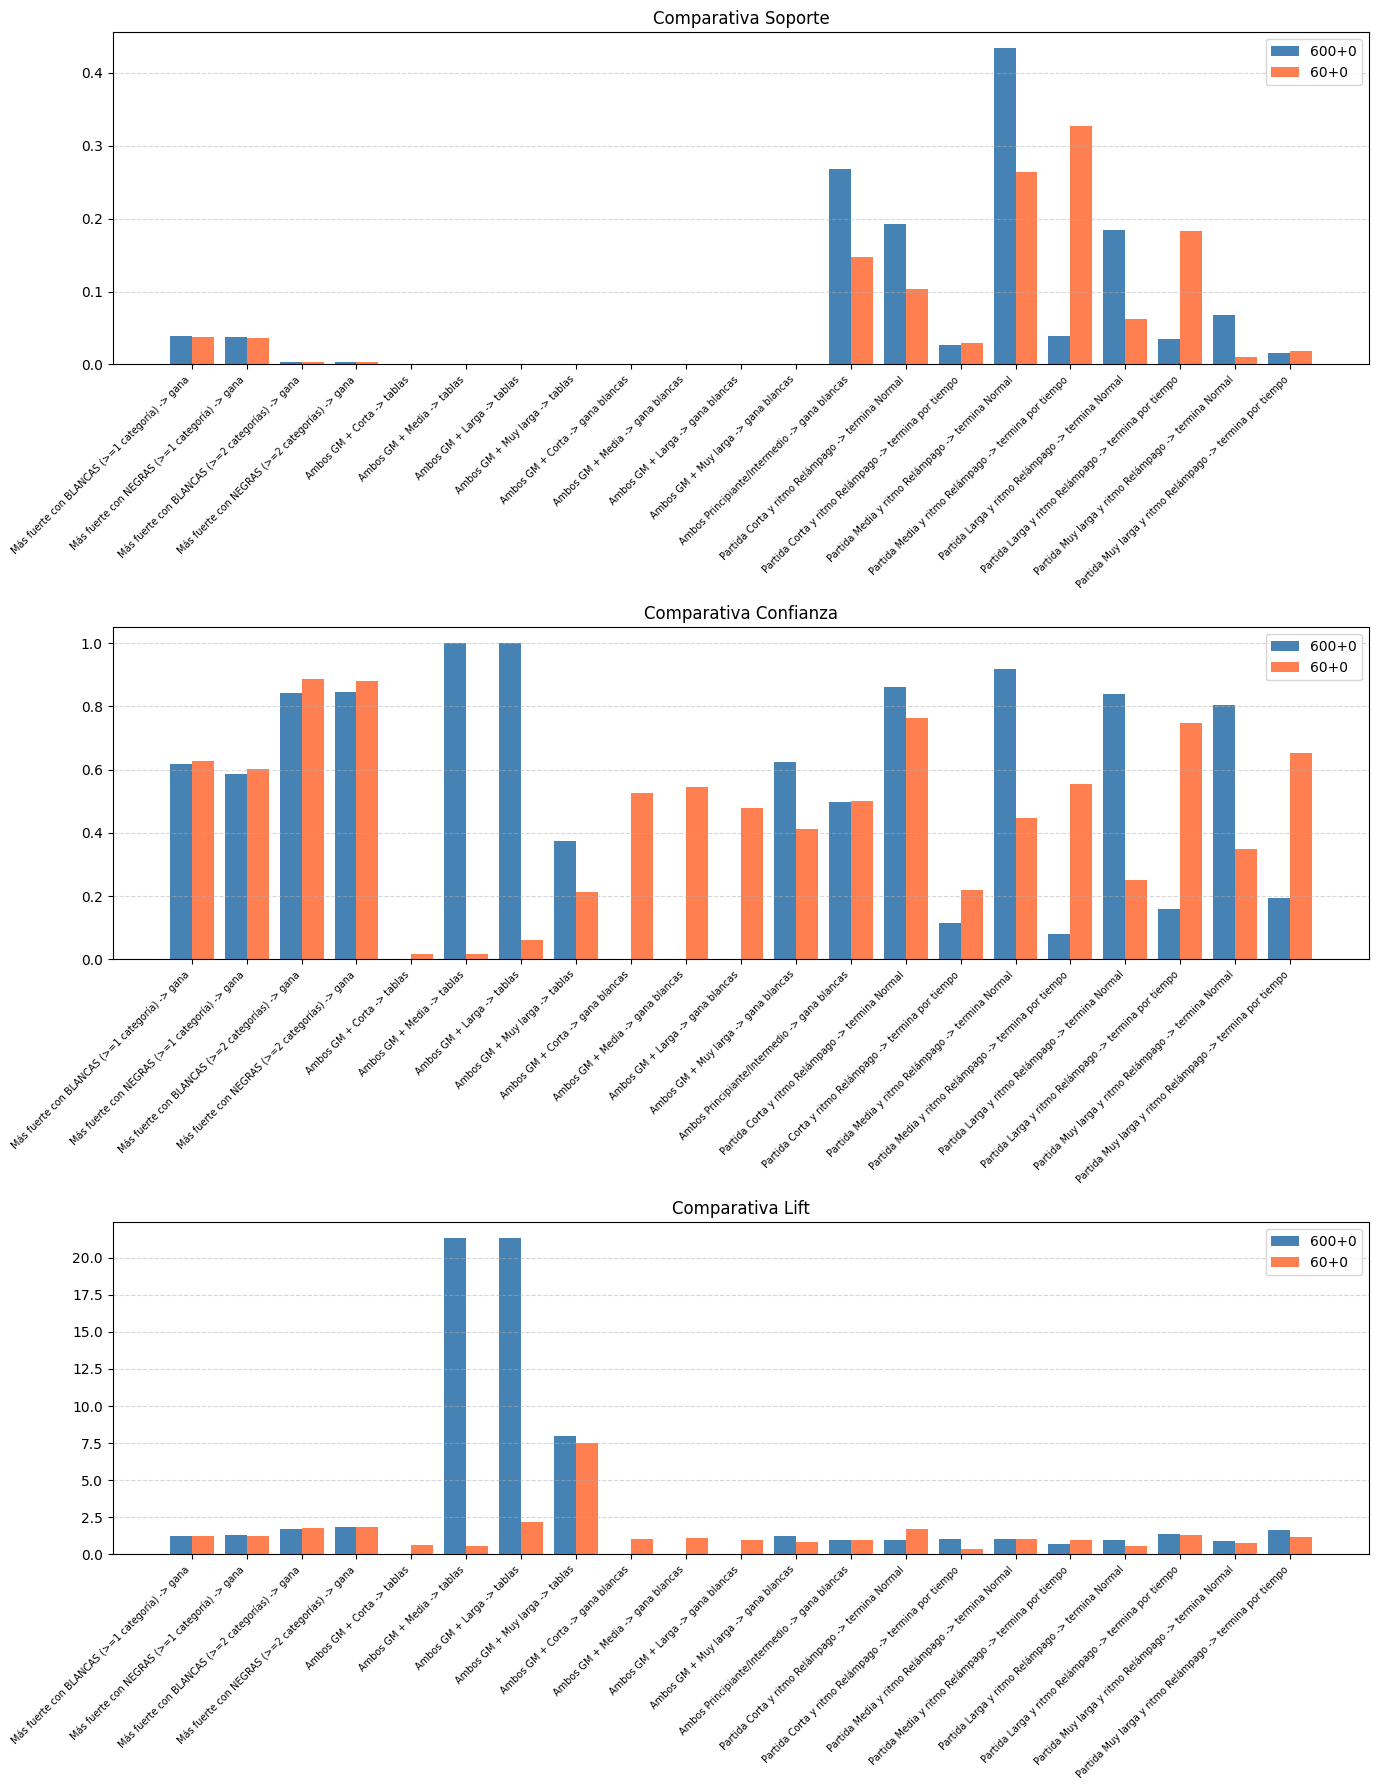

In [22]:
import matplotlib.pyplot as plt

df_resultados = pd.DataFrame(resultados)

# Esto hará que se muestre la tabla con las métricas calculadas para cada regla
print(df_resultados.to_string(index=False))

# Luego, se crean las gráficas, una para cada métrica, comparando los resultados de ambos subconjuntos
metricas = ['Soporte', 'Confianza', 'Lift']
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

for ax, metrica in zip(axes, metricas):
    df_600_res = df_resultados[df_resultados['Subset'] == '600+0']
    df_60_res  = df_resultados[df_resultados['Subset'] == '60+0']
    
    x = range(len(df_600_res))
    x2 = range(len(df_60_res))
    width = 0.4
    
    ax.bar([i - width/2 for i in x], df_600_res[metrica], width=width, label='600+0', color='steelblue')
    ax.bar([i + width/2 for i in x2], df_60_res[metrica],  width=width, label='60+0',  color='coral')
    
    ax.set_title(f'Comparativa {metrica}')
    ax.set_xticks(list(x))
    ax.set_xticklabels(df_600_res['Regla'], rotation=45, ha='right', fontsize=7)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('comparativa_reglas.png', dpi=150, bbox_inches='tight')
plt.show()